# Greeks Validation and P&L Attribution

This notebook validates the finite-difference Greek estimators in 
`option_pricing.monte_carlo.mc_european_option_greeks` against the analytical 
Black-Scholes Greeks in `option_pricing.black_scholes`, and demonstrates their 
application in a one-day P&L attribution exercise.

All experiments use a standard ATM European call as reference: 
S₀ = K = 100, T = 1 year, r = 5%, σ = 20%.

## Research Questions

This notebook addresses four research questions, extending the prior study 
on Monte Carlo option pricing:

5. **Convergence** — Do MC finite-difference Greeks converge to analytical 
   Black-Scholes Greeks, and at what rate?
6. **Bump size sensitivity** — How does the choice of bump size affect 
   finite-difference accuracy, and is there an optimal bump for each Greek?
7. **CRN effectiveness** — How much does fixing the random seed (Common 
   Random Numbers) reduce variance in Greek estimation?
8. **P&L attribution** — Can a first- and second-order Greek expansion 
   accurately approximate one-day option P&L?

In [1]:
import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats

from option_pricing.black_scholes import (
    bs_call_price, bs_put_price,
    bs_call_delta, bs_put_delta,
    bs_gamma, bs_vega,
    bs_call_theta, bs_put_theta,
)
from option_pricing.monte_carlo import (
    mc_european_option_price,
    mc_barrier_option_price,
    mc_european_option_greeks,
)

pd.set_option("display.float_format", "{:.5f}".format)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

warnings.filterwarnings("ignore")
print("Environment ready.")

Environment ready.


## Setup — Reference Values from Black-Scholes

We start by computing the analytical Black-Scholes price and Greeks for the 
reference ATM option. These values serve as the benchmark against which all 
Monte Carlo estimates in subsequent experiments are validated. The put-call 
parity residual provides a first sanity check on the analytical pricers.

In [2]:
S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

call_bs = bs_call_price(S0, K, T, r, sigma)
call_bs_delta = bs_call_delta(S0, K, T, r, sigma)
call_theta = bs_call_theta(S0, K, T, r, sigma)
put_bs  = bs_put_price(S0, K, T, r, sigma)
put_bs_delta = bs_put_delta(S0, K, T, r, sigma)
put_theta = bs_put_theta(S0, K, T, r, sigma)
gamma = bs_gamma(S0, K, T, r, sigma)
vega = bs_vega(S0, K, T, r, sigma)

print(f"European call (BS):  {call_bs:.6f}")
print(f"European call delta (BS): {call_bs_delta:.6f}")
print(f"European call theta (BS): {call_theta:.6f}")
print(f"European put  (BS):  {put_bs:.6f}")
print(f"European put delta (BS): {put_bs_delta:.6f}")
print(f"European put theta (BS): {put_theta:.6f}")
print(f"European gamma (BS): {gamma:.6f}")
print(f"European vega (BS): {vega:.6f}")

import math
parity_err = abs(call_bs - put_bs - S0 + K * math.exp(-r * T))
print(f"Put-call parity residual: {parity_err:.2e}")

European call (BS):  10.450584
European call delta (BS): 0.636831
European call theta (BS): -0.025452
European put  (BS):  5.573526
European put delta (BS): -0.363169
European put theta (BS): -0.006579
European gamma (BS): 0.018762
European vega (BS): 0.375240
Put-call parity residual: 0.00e+00


---
## Experiment 1 — Option Prices and Greek Profiles vs Spot


We begin by examining the analytical Black-Scholes Greeks across a range of spot prices for a standard ATM European option (K = 100, T = 1 year, r = 5%, σ = 20%). These profiles serve as the benchmark against which all Monte Carlo estimates will be validated in subsequent sections. Understanding the shapes — particularly where each Greek is largest and where it changes fastest — is essential for interpreting the convergence results that follow.



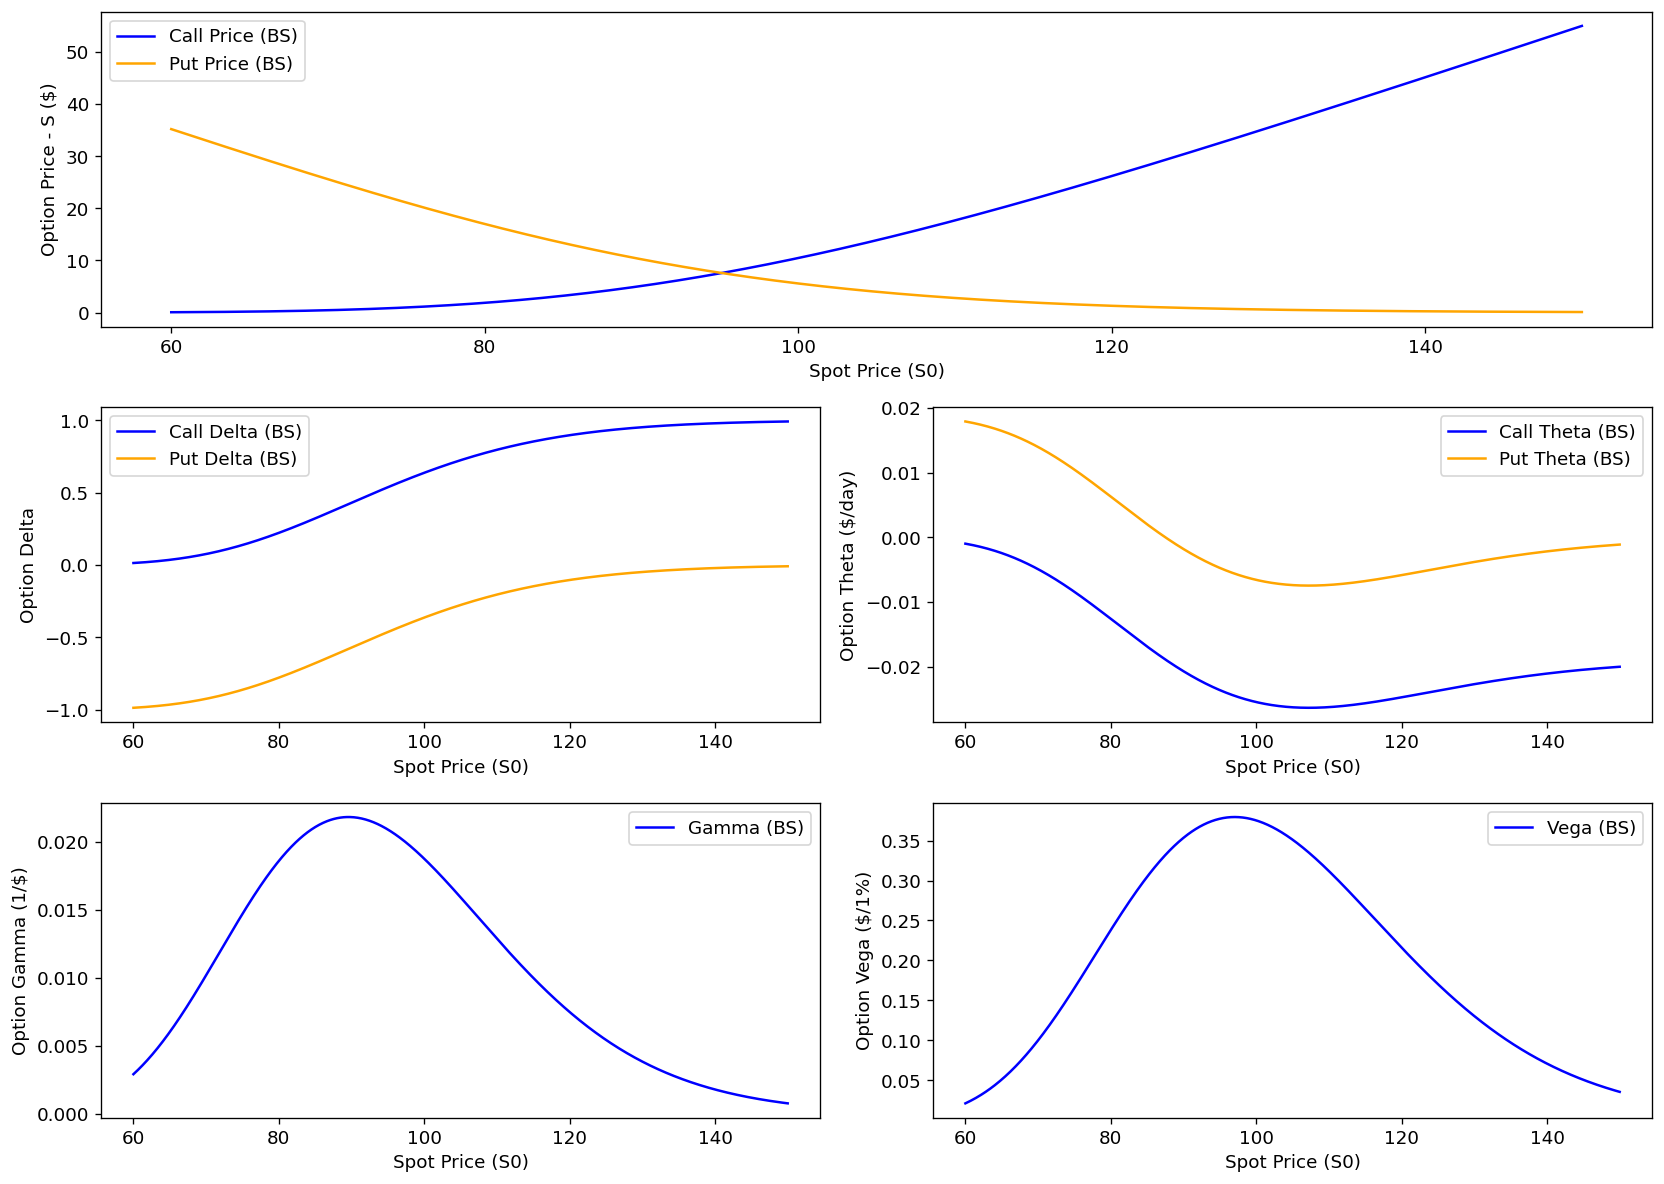

In [3]:
S0_vector = np.linspace(60, 150, 1001)
K, T, r, sigma = 100.0, 1.0, 0.05, 0.20

call_bs_vector = np.array([bs_call_price(s0_value, K, T, r, sigma) for s0_value in S0_vector])
call_bs_delta_vector = np.array([bs_call_delta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
call_bs_theta_vector = np.array([bs_call_theta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
put_bs_vector  = np.array([bs_put_price(s0_value, K, T, r, sigma) for s0_value in S0_vector])
put_bs_delta_vector = np.array([bs_put_delta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
put_bs_theta_vector = np.array([bs_put_theta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
gamma_bs_vector = np.array([bs_gamma(s0_value, K, T, r, sigma) for s0_value in S0_vector])
vega_bs_vector = np.array([bs_vega(s0_value, K, T, r, sigma) for s0_value in S0_vector])

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

gs = axes[0, 0].get_gridspec()
# remove the underlying Axes
for ax in axes[0, 0:2]:
    ax.remove()
axcenter = fig.add_subplot(gs[0, 0:2])

axcenter.plot(S0_vector, call_bs_vector, label="Call Price (BS)", color="blue")
axcenter.plot(S0_vector, put_bs_vector, label="Put Price (BS)", color="orange")

axcenter.set_xlabel("Spot Price (S0)")
axcenter.set_ylabel("Option Price - S ($)")
axcenter.legend()

axes[1, 0].plot(S0_vector, call_bs_delta_vector, label="Call Delta (BS)", color="blue")
axes[1, 0].plot(S0_vector, put_bs_delta_vector, label="Put Delta (BS)", color="orange")

axes[1, 0].set_xlabel("Spot Price (S0)")
axes[1, 0].set_ylabel("Option Delta")
axes[1, 0].legend()

axes[1, 1].plot(S0_vector, call_bs_theta_vector, label="Call Theta (BS)", color="blue")
axes[1, 1].plot(S0_vector, put_bs_theta_vector, label="Put Theta (BS)", color="orange")
axes[1, 1].set_xlabel("Spot Price (S0)")
axes[1, 1].set_ylabel("Option Theta ($/day)")
axes[1, 1].legend()

axes[2, 0].plot(S0_vector, gamma_bs_vector, label="Gamma (BS)", color="blue")
axes[2, 0].set_xlabel("Spot Price (S0)")
axes[2, 0].set_ylabel("Option Gamma (1/$)")
axes[2, 0].legend()

axes[2, 1].plot(S0_vector, vega_bs_vector, label="Vega (BS)", color="blue")
axes[2, 1].set_xlabel("Spot Price (S0)")
axes[2, 1].set_ylabel("Option Vega ($/1%)")
axes[2, 1].legend()


plt.tight_layout()
plt.show()

**Prices**: Call and put prices are convex functions of spot. They meet near ATM where both have positive value. Deep OTM options approach zero; deep ITM options approach their intrinsic value. The convexity visible here is what Gamma measures.

**Delta**: Call Delta transitions smoothly from 0 (deep OTM) to 1 (deep ITM), passing through approximately 0.5 at ATM. Put Delta mirrors this from −1 to 0. The transition is steepest at ATM — meaning Delta changes fastest there per unit move in spot. This is the region where dynamic hedging requires the most frequent rebalancing.

**Theta**: Both call and put Theta are most negative at ATM, where time value is largest and therefore decays fastest. Deep ITM and OTM options have little time value left to lose, so Theta is close to zero there. Note that call and put Theta are nearly identical in this parameter regime — this follows from put-call parity.

**Gamma**: Gamma is identical for calls and puts (this is exact, not approximate) and peaks sharply at ATM. This has a direct implication for Monte Carlo estimation: the region where Gamma is largest is precisely where finite-difference estimation is hardest, because the second derivative amplifies any noise in the bumped price evaluations. This motivates the convergence analysis in Section 2.

**Vega**: Vega has the same bell shape as Gamma and is also identical for calls and puts. It peaks at ATM, meaning ATM options are the most sensitive to changes in implied volatility. A trader who is long an ATM option profits from a vol spike; one who is short loses. This plot is the visual foundation for understanding vega hedging.

These profiles define the landscape for the MC convergence study. The ATM point (S0 = 100) is where Greek estimation is most demanding — Gamma and Vega are at their maximum, and Delta is changing fastest. All subsequent MC experiments use ATM parameters precisely because this represents the hardest case.

---
## Experiment 2 — Option Prices and Greek Profiles vs Time Maturity

With spot fixed at ATM (S0 = K = 100), we now examine how each Greek evolves as time to expiry T decreases from 2 years to a single trading day (1/252). This perspective is essential for understanding the risks that build up as an option approaches expiration — risks that are invisible when looking at a fixed-maturity snapshot.

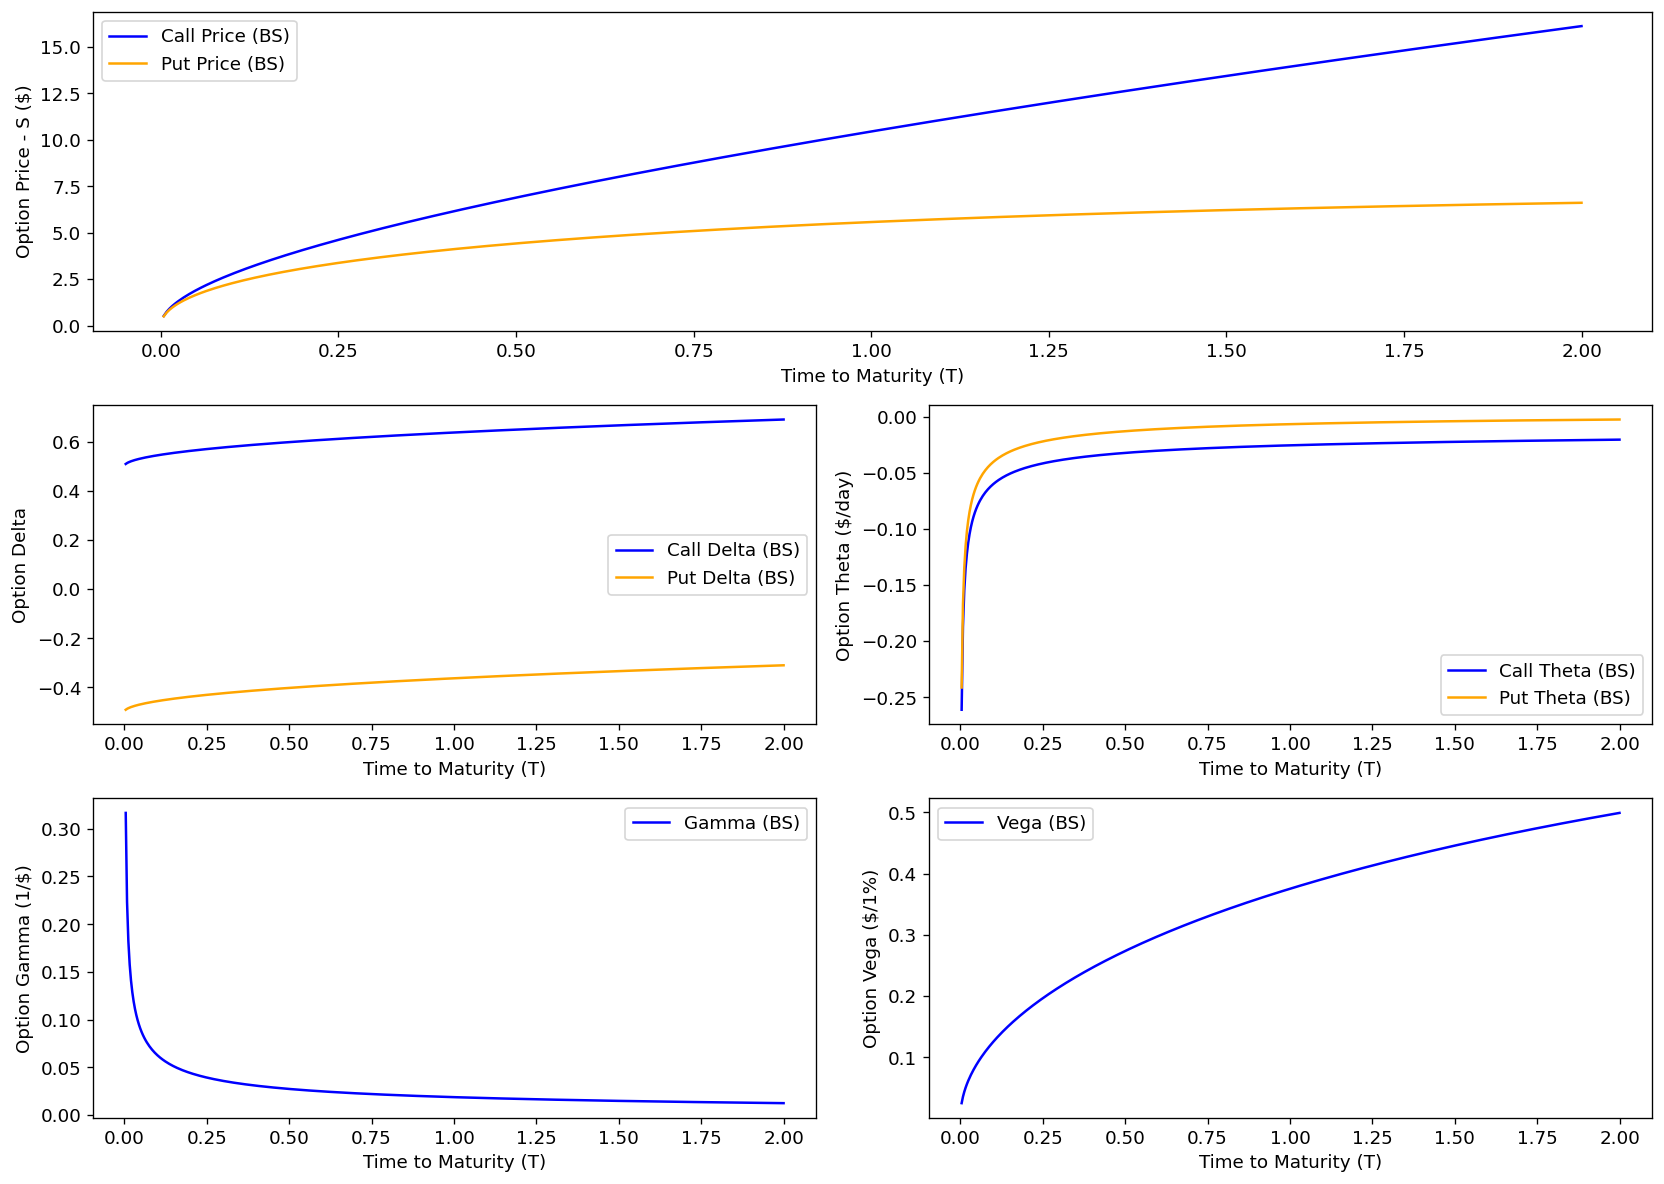

In [4]:
S0    = 100.0   # ATM spot
K     = 100.0   # strike
r     = 0.05    # 5% risk-free rate
sigma = 0.20    # 20% vol
T_vector = np.linspace(2.0, 1/252, 500)  # T varies


call_bs_vector = np.array([bs_call_price(S0, K, T, r, sigma) for T in T_vector])
call_bs_delta_vector = np.array([bs_call_delta(S0, K, T, r, sigma) for T in T_vector])
call_bs_theta_vector = np.array([bs_call_theta(S0, K, T, r, sigma) for T in T_vector])
put_bs_vector  = np.array([bs_put_price(S0, K, T, r, sigma) for T in T_vector])
put_bs_delta_vector = np.array([bs_put_delta(S0, K, T, r, sigma) for T in T_vector])
put_bs_theta_vector = np.array([bs_put_theta(S0, K, T, r, sigma) for T in T_vector])
gamma_bs_vector = np.array([bs_gamma(S0, K, T, r, sigma) for T in T_vector])
vega_bs_vector = np.array([bs_vega(S0, K, T, r, sigma) for T in T_vector])

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

gs = axes[0, 0].get_gridspec()
# remove the underlying Axes
for ax in axes[0, 0:2]:
    ax.remove()
axcenter = fig.add_subplot(gs[0, 0:2])

axcenter.plot(T_vector, call_bs_vector, label="Call Price (BS)", color="blue")
axcenter.plot(T_vector, put_bs_vector, label="Put Price (BS)", color="orange")

axcenter.set_xlabel("Time to Maturity (T)")
axcenter.set_ylabel("Option Price - S ($)")
axcenter.legend()

axes[1, 0].plot(T_vector, call_bs_delta_vector, label="Call Delta (BS)", color="blue")
axes[1, 0].plot(T_vector, put_bs_delta_vector, label="Put Delta (BS)", color="orange")

axes[1, 0].set_xlabel("Time to Maturity (T)")
axes[1, 0].set_ylabel("Option Delta")
axes[1, 0].legend()

axes[1, 1].plot(T_vector, call_bs_theta_vector, label="Call Theta (BS)", color="blue")
axes[1, 1].plot(T_vector, put_bs_theta_vector, label="Put Theta (BS)", color="orange")
axes[1, 1].set_xlabel("Time to Maturity (T)")
axes[1, 1].set_ylabel("Option Theta ($/day)")
axes[1, 1].legend()

axes[2, 0].plot(T_vector, gamma_bs_vector, label="Gamma (BS)", color="blue")
axes[2, 0].set_xlabel("Time to Maturity (T)")
axes[2, 0].set_ylabel("Option Gamma (1/$)")
axes[2, 0].legend()

axes[2, 1].plot(T_vector, vega_bs_vector, label="Vega (BS)", color="blue")
axes[2, 1].set_xlabel("Time to Maturity (T)")
axes[2, 1].set_ylabel("Option Vega ($/1%)")
axes[2, 1].legend()


plt.tight_layout()
plt.show()

**Prices**: Both call and put prices increase with T, growing roughly as √T. More time means more opportunity for the underlying to move favorably, so options are always worth more with longer maturity. The call grows faster than the put due to the interest rate effect — longer maturity increases the present-value benefit of deferring the strike payment.

**Delta**: Call Delta rises from approximately 0.5 at T→0 to 0.67 at T=2 years. This is because d1 = (r + σ²/2)√T/σ increases with T, pushing N(d1) above 0.5. The ATM call becomes increasingly in-the-money in a risk-neutral sense as maturity lengthens. Put Delta mirrors this from −0.5 toward −0.33. Of the four Greeks, Delta is the most stable across maturities.

**Theta**: Theta explodes negatively as T→0, reaching approximately −$0.25 per day at expiry. This is the "last day" problem — an ATM option that expires tomorrow will lose almost all its remaining time value in 24 hours. As T increases, Theta flattens toward zero: a 2-year option loses very little value per day because the daily time decay is spread over 500+ remaining trading days.

**Gamma**: Gamma diverges as T→0, proportional to 1/√T for an ATM option. A near-expiry ATM option has almost infinite curvature — a $1 move in spot can completely flip whether it expires in- or out-of-the-money. This is why option sellers face "pin risk" at expiry: Gamma is unmanageably large precisely when the position is closest to resolution. As T increases, Gamma decays smoothly toward zero.

**Vega**: Vega behaves oppositely to Gamma — it collapses toward zero as T→0 and grows as T increases. An option expiring tomorrow has almost no sensitivity to implied volatility because there is no time left for volatility to affect the outcome. Longer-dated options are the primary vehicle for vol trading precisely because their Vega is large.

The most important relationship visible in this plot is between Gamma and Theta. They move together: when Gamma is large and positive (near expiry), Theta is large and negative. This is not a coincidence — it is enforced by the Black-Scholes PDE. For a Delta-neutral position: Theta ≈ −½ σ² S² Gamma. You cannot have the convexity benefit of high Gamma without paying the daily time decay of negative Theta. This tradeoff is the central tension in options trading and risk management.


---
## Experiment 3 — Convergence of Estimated Values to BS Benchmark

This first view shows the seed-averaged Greek estimates as N increases, 
with the analytical BS benchmark as a dashed reference line. CIs are computed 
across 30 seeds at each N. The complementary error view, which makes the 
convergence rate explicit, follows in Experiment 4.

In [5]:
S0    = 100.0   # ATM spot
K     = 100.0   # strike
r     = 0.05    # 5% risk-free rate
sigma = 0.20    # 20% vol
T = 1

random_seed=42
path_grid=[1_000, 5_000, 10_000, 50_000, 100_000, 200_000, 500_000]


mc_greeks = mc_european_option_greeks(S0, K, T, r, sigma, 'call',path_grid[-1], random_seed,)

def run_mc_greeks_experiment(S0, K, T, r, sigma, path_grid):
    
    # Compute analytical benchmarks once, outside all loops
    benchmarks = {
        "delta": bs_call_delta(S0, K, T, r, sigma),
        "gamma": bs_gamma(S0, K, T, r, sigma),
        "vega":  bs_vega(S0, K, T, r, sigma),
        "theta": bs_call_theta(S0, K, T, r, sigma),
    }

    # list of dicts to build DataFrame later
    rows: list[dict] = []

    #Loop over path counts and seeds, collect results and runtimes
    for n_paths in path_grid:
        for used_seed in range(30):
            t0 = time.perf_counter()
            res = mc_european_option_greeks(
                S0=S0, K=K, T=T, r=r, sigma=sigma,
                option_type="call",
                n_paths=n_paths,
                random_seed=used_seed,
            )
            rt = time.perf_counter() - t0

            rows.append({
                "n_paths":   n_paths,
                "delta":  res.delta,
                "gamma":  res.gamma,
                "vega":   res.vega,
                "theta":  res.theta,
                "runtime_s": rt,
            })

        
    df = pd.DataFrame(rows)
    # Add absolute error columns using benchmarks
    for greek, bs_val in benchmarks.items():
        df[f"{greek}_error"] = np.abs(df[greek] - bs_val)
    return df

def aggregate_greeks_experiment(df: pd.DataFrame) -> pd.DataFrame:
    def se(x: pd.Series) -> float:
        return x.std(ddof=1) / np.sqrt(len(x))

    agg =  (
        df.groupby("n_paths")
        .agg(
            delta=("delta", "mean"),
            delta_mean_error=("delta_error", "mean"),
            delta_se        =("delta_error", se),
            gamma=("gamma", "mean"),
            gamma_mean_error=("gamma_error", "mean"),
            gamma_se        =("gamma_error", se),
            vega=("vega", "mean"),
            vega_mean_error =("vega_error",  "mean"),
            vega_se         =("vega_error",  se),
            theta=("theta", "mean"),
            theta_mean_error=("theta_error", "mean"),
            theta_se        =("theta_error", se),
            runtime_mean    =("runtime_s",   "mean"),
        )
        .reset_index()
    )

    # se / mean_error computed after aggregation
    for greek in ["delta", "gamma", "vega", "theta"]:
        agg[f"{greek}_ratio"] = agg[f"{greek}_se"] / agg[f"{greek}_mean_error"]
    
    return agg

benchmarks_dict = {
        "delta": bs_call_delta(S0, K, T, r, sigma),
        "gamma": bs_gamma(S0, K, T, r, sigma),
        "vega":  bs_vega(S0, K, T, r, sigma),
        "theta": bs_call_theta(S0, K, T, r, sigma),
    }

df_raw = run_mc_greeks_experiment(S0, K, T, r, sigma, path_grid)
agg_df  = aggregate_greeks_experiment(df_raw)

### Aggregated Greek Estimates Across 30 Seeds

The table below summarises the experiment: for each path count, it shows the 
seed-averaged Greek estimate, the mean absolute error against the BS benchmark, 
the standard error of that error across seeds, and the coefficient of variation 
(`{greek}_ratio = se / mean_error`).

In [6]:
agg_df

,n_paths,delta,delta_mean_error,delta_se,gamma,gamma_mean_error,gamma_se,vega,vega_mean_error,vega_se,theta,theta_mean_error,theta_se,runtime_mean,delta_ratio,gamma_ratio,vega_ratio,theta_ratio
0,1000,0.63321,0.01768,0.00200,0.01850,0.00310,0.00039,0.36493,0.01838,0.00338,-0.02503,0.00092,0.00016,0.00022,0.11299,0.12590,0.18395,0.16966
1,5000,0.63956,0.01050,0.00099,0.01866,0.00105,0.00014,0.37722,0.00893,0.00133,-0.02559,0.00050,0.00006,0.00051,0.09441,0.13128,0.14946,0.12820
2,10000,0.63830,0.00558,0.00068,0.01874,0.00076,0.00012,0.37546,0.00632,0.00079,-0.02550,0.00032,0.00004,0.00086,0.12216,0.15796,0.12451,0.11764
3,50000,0.63741,0.00199,0.00028,0.01874,0.00031,0.00005,0.37446,0.00260,0.00037,-0.02545,0.00012,0.00002,0.00372,0.13962,0.15810,0.14259,0.15346
4,100000,0.63714,0.00106,0.00016,0.01878,0.00022,0.00003,0.37469,0.00159,0.00029,-0.02546,0.00007,0.00001,0.00791,0.15525,0.12009,0.18154,0.15992
5,200000,0.63718,0.00078,0.00012,0.01879,0.00017,0.00002,0.37525,0.00127,0.00016,-0.02548,0.00006,0.00001,0.03648,0.15262,0.11066,0.12332,0.14858
6,500000,0.63701,0.00077,0.00009,0.01877,0.00013,0.00002,0.37514,0.00101,0.00016,-0.02547,0.00005,0.00001,0.08777,0.11255,0.13173,0.15310,0.12686


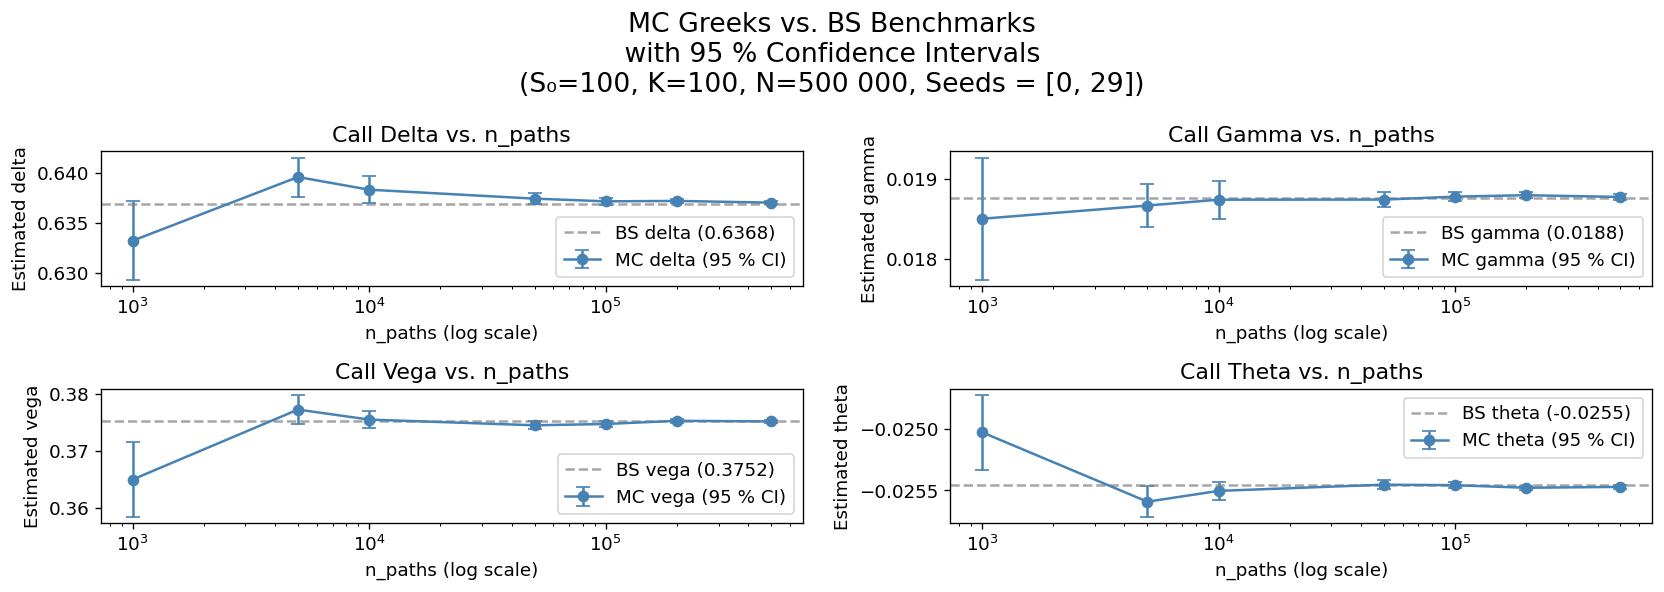

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 5))

axes[0, 0].errorbar(
    agg_df["n_paths"], agg_df["delta"],
    yerr=1.96 * agg_df["delta_se"],
    marker="o", capsize=4, color="steelblue", label="MC delta (95 % CI)"
)

benchmark_bs_delta = benchmarks_dict["delta"]
axes[0, 0].axhline(benchmark_bs_delta, ls="--", color="grey", alpha=0.7,
                label=f"BS delta ({benchmark_bs_delta:.4f})")
axes[0, 0].set_xscale("log")
axes[0, 0].set_xlabel("n_paths (log scale)")
axes[0, 0].set_ylabel("Estimated delta")
axes[0, 0].set_title("Call Delta vs. n_paths")
axes[0, 0].legend()

axes[0, 1].errorbar(
    agg_df["n_paths"], agg_df["gamma"],
    yerr=1.96 * agg_df["gamma_se"],
    marker="o", capsize=4, color="steelblue", label="MC gamma (95 % CI)"
)

benchmark_bs_gamma = benchmarks_dict["gamma"]
axes[0, 1].axhline(benchmark_bs_gamma, ls="--", color="grey", alpha=0.7,
                label=f"BS gamma ({benchmark_bs_gamma:.4f})")
axes[0, 1].set_xscale("log")
axes[0, 1].set_xlabel("n_paths (log scale)")
axes[0, 1].set_ylabel("Estimated gamma")
axes[0, 1].set_title("Call Gamma vs. n_paths")
axes[0, 1].legend()

axes[1, 0].errorbar(
    agg_df["n_paths"], agg_df["vega"],
    yerr=1.96 * agg_df["vega_se"],
    marker="o", capsize=4, color="steelblue", label="MC vega (95 % CI)"
)

benchmark_bs_vega = benchmarks_dict["vega"]
axes[1, 0].axhline(benchmark_bs_vega, ls="--", color="grey", alpha=0.7,
                label=f"BS vega ({benchmark_bs_vega:.4f})")
axes[1, 0].set_xscale("log")
axes[1, 0].set_xlabel("n_paths (log scale)")
axes[1, 0].set_ylabel("Estimated vega")
axes[1, 0].set_title("Call Vega vs. n_paths")
axes[1, 0].legend()

axes[1, 1].errorbar(
    agg_df["n_paths"], agg_df["theta"],
    yerr=1.96 * agg_df["theta_se"],
    marker="o", capsize=4, color="steelblue", label="MC theta (95 % CI)"
)

benchmark_bs_theta = benchmarks_dict["theta"]
axes[1, 1].axhline(benchmark_bs_theta, ls="--", color="grey", alpha=0.7,
                label=f"BS theta ({benchmark_bs_theta:.4f})")
axes[1, 1].set_xscale("log")
axes[1, 1].set_xlabel("n_paths (log scale)")
axes[1, 1].set_ylabel("Estimated theta")
axes[1, 1].set_title("Call Theta vs. n_paths")
axes[1, 1].legend()

plt.suptitle("MC Greeks vs. BS Benchmarks\n with 95 % Confidence Intervals \n(S₀=100, K=100, N=500 000, Seeds = [0, 29])", fontsize=16)

plt.tight_layout()
plt.show()

For all four Greeks, the estimated values oscillate around the BS benchmark at low N — crossing it and overshooting before stabilizing. This is expected: the MC estimator is unbiased, meaning it oscillates symmetrically around the true value, but at low path counts the 30-seed average is still noisy enough to land on either side. What converges monotonically is not the estimated value itself but the mean absolute error, as one can see in the table.

---
## Experiment 4 —  Log-Log Convergence Rate

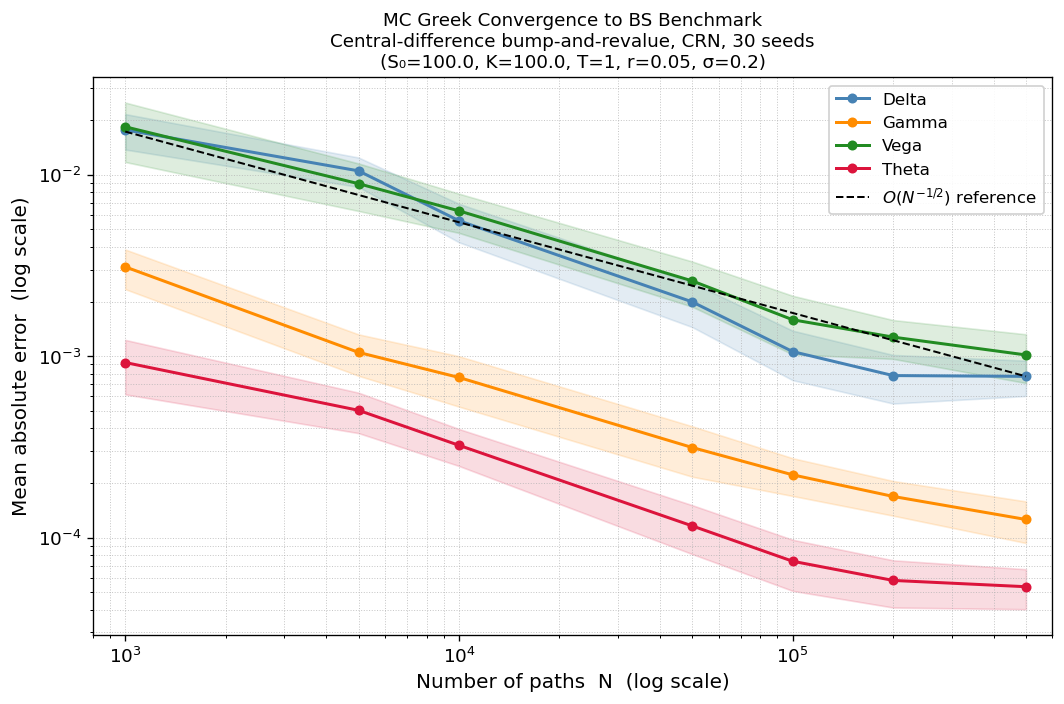

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

colors = {"delta": "steelblue", "gamma": "darkorange",
          "vega": "forestgreen", "theta": "crimson"}

for greek, color in colors.items():
    mean = agg_df[f"{greek}_mean_error"].to_numpy()
    se   = agg_df[f"{greek}_se"].to_numpy()
    n    = agg_df["n_paths"].to_numpy()

    ax.loglog(n, mean, marker="o", color=color,
              linewidth=1.8, markersize=5, label=greek.capitalize())
    ax.fill_between(
        n,
        np.maximum(mean - 1.96 * se, 1e-6),  # clip negative lower bound
        mean + 1.96 * se,
        alpha=0.15, color=color,
    )

# O(N^{-0.5}) reference slope
n_ref  = np.array([n.min(), n.max()])
anchor = agg_df["delta_mean_error"].iloc[-1] * (n.max() ** 0.5)
ax.loglog(n_ref, anchor * n_ref ** -0.5,
          color="black", linestyle="--", linewidth=1.2,
          label=r"$O(N^{-1/2})$ reference")

ax.set_xlabel("Number of paths  N  (log scale)", fontsize=12)
ax.set_ylabel("Mean absolute error  (log scale)", fontsize=12)
ax.set_title(
    "MC Greek Convergence to BS Benchmark\n"
    r"Central-difference bump-and-revalue, CRN, 30 seeds"
    f"\n(S₀={S0}, K={K}, T={T}, r={r}, σ={sigma})",
    fontsize=11,
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)
ax.set_xlim(n.min() * 0.8, n.max() * 1.2)

plt.tight_layout()
plt.show()


All four Greeks converge at the empirical O(N⁻¹/²) rate, consistent with theory. The lines are parallel on the log-log scale — the convergence rate is identical for all Greeks. What differs is the prefactor, visible as the vertical separation between curves.
The ordering from largest to smallest mean absolute error is consistent across all N: Delta and Vega carry the largest errors (0.0177 and 0.0184 at N=1,000), Gamma sits roughly 6× smaller (0.0031), and Theta is the smallest of all (0.0009). This ordering reflects the scale of each Greek: Delta is close to 0.637, Vega to 0.375, while Theta is only −0.025. A smaller-magnitude Greek naturally produces a smaller absolute error at the same relative precision.
The se/mean_error ratios — the coefficient of variation of each error estimate — remain stable between 11% and 18% across all N and all Greeks. This is expected: both se and mean_error decrease at the same O(N⁻¹/²) rate so their ratio stays constant. At 30 seeds, our error estimates carry approximately 12–16% relative uncertainty throughout.

---
## Experiment 5 —  bump size sensitivity

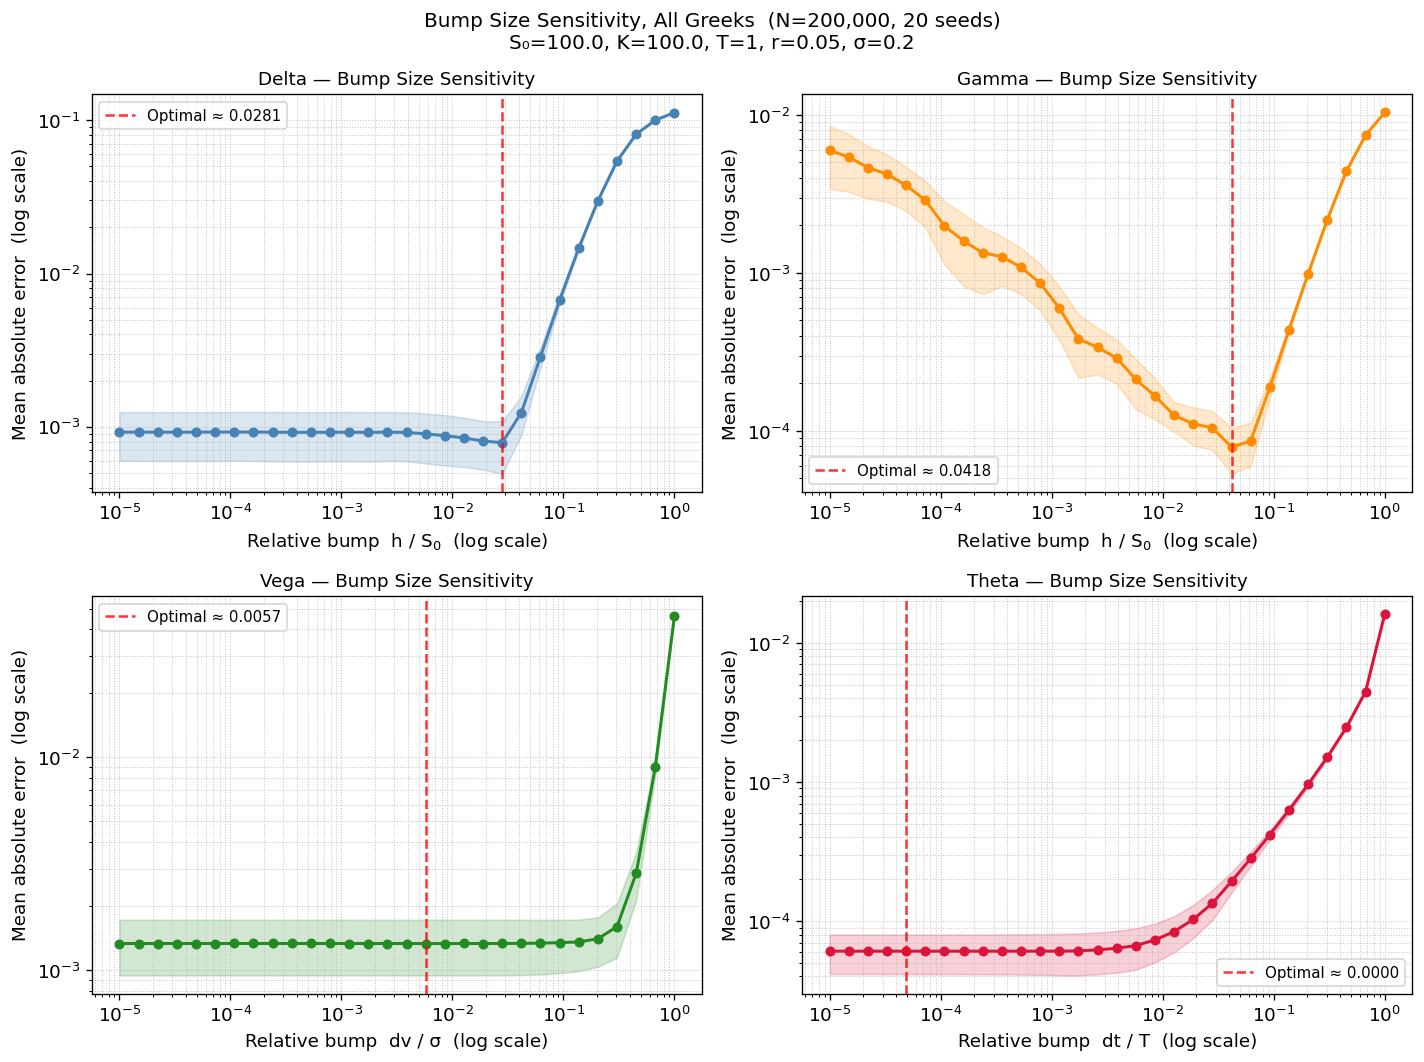

In [9]:
# ── Experiment ────────────────────────────────────────────────────────────────
def run_bump_sensitivity_experiment(
    S0: float, K: float, T: float, r: float, sigma: float,
    n_paths: int = 200_000,
    n_seeds: int = 20,
    n_bumps: int = 30,
) -> pd.DataFrame:
    """Vary relative bump size and measure all four Greek errors vs analytical BS.

    A single relative bump fraction f is used for each parameter:
      Delta / Gamma : h  = f * S0
      Vega          : dv = f * sigma
      Theta         : dt = f * T

    Using a relative bump keeps the four Greeks comparable on the same axis.
    Vega is reported per 1 vol point; Theta per calendar day.
    All pricing calls use CRN (same seed across base and bumped evaluations).
    """
    bump_grid = np.logspace(-5, 0, n_bumps)

    bs_vals = {
        "delta": bs_call_delta(S0, K, T, r, sigma),
        "gamma": bs_gamma(S0, K, T, r, sigma),
        "vega":  bs_vega(S0, K, T, r, sigma),
        "theta": bs_call_theta(S0, K, T, r, sigma),
    }

    rows: list[dict] = []

    for f in bump_grid:
        h, dv, dt = f * S0, f * sigma, f * T
        errors = {g: [] for g in bs_vals}

        for seed in range(n_seeds):
            def _price(S_=S0, sigma_=sigma, T_=T):
                return mc_european_option_price(
                    S0=S_, K=K, T=T_, r=r, sigma=sigma_,
                    n_paths=n_paths, antithetic=False, random_seed=seed,
                ).price

            base   = _price()
            s_up   = _price(S_=S0 + h)
            s_down = _price(S_=S0 - h)
            v_up   = _price(sigma_=sigma + dv)
            v_down = _price(sigma_=sigma - dv)
            t_down = _price(T_=T - dt)

            estimates = {
                "delta": (s_up - s_down) / (2 * h),
                "gamma": (s_up - 2 * base + s_down) / h ** 2,
                "vega":  (v_up - v_down) / (2 * dv) / 100,
                "theta": (t_down - base) / dt/252,
            }
            for g, est in estimates.items():
                errors[g].append(abs(est - bs_vals[g]))

        row = {"bump_rel": f}
        for g in bs_vals:
            arr = np.array(errors[g])
            row[f"{g}_mean_error"] = arr.mean()
            row[f"{g}_se"]         = arr.std(ddof=1) / np.sqrt(n_seeds)
        rows.append(row)

    return pd.DataFrame(rows)


# ── Plot ──────────────────────────────────────────────────────────────────────
bump_df = run_bump_sensitivity_experiment(S0, K, T, r, sigma)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

colors = {"delta": "steelblue", "gamma": "darkorange",
          "vega":  "forestgreen", "theta": "crimson"}
bump_label = {"delta": r"h / S$_0$", "gamma": r"h / S$_0$",
              "vega":  r"dv / σ",    "theta": r"dt / T"}

for ax, greek in zip(axes.flat, ["delta", "gamma", "vega", "theta"]):
    mean_err = bump_df[f"{greek}_mean_error"].to_numpy()
    se       = bump_df[f"{greek}_se"].to_numpy()
    rel      = bump_df["bump_rel"].to_numpy()

    ax.loglog(rel, mean_err, marker="o", color=colors[greek],
              linewidth=1.8, markersize=5)
    ax.fill_between(
        rel,
        np.maximum(mean_err - 1.96 * se, 1e-10),
        mean_err + 1.96 * se,
        alpha=0.2, color=colors[greek],
    )

    opt_idx = np.argmin(mean_err)
    ax.axvline(
        rel[opt_idx], color="red", linestyle="--", alpha=0.8,
        label=f"Optimal ≈ {rel[opt_idx]:.4f}",
    )
    ax.set_xlabel(f"Relative bump  {bump_label[greek]}  (log scale)", fontsize=11)
    ax.set_ylabel("Mean absolute error  (log scale)", fontsize=11)
    ax.set_title(f"{greek.capitalize()} — Bump Size Sensitivity", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)

fig.suptitle(
    f"Bump Size Sensitivity, All Greeks  (N=200,000, 20 seeds)\n"
    f"S₀={S0}, K={K}, T={T}, r={r}, σ={sigma}",
    fontsize=12,
)
plt.tight_layout()
plt.show()

Figure 3 extends the bump size sensitivity study to all four Greeks. To keep them comparable on the same axis, we use a single relative bump fraction f applied to each parameter being bumped: h = f·S₀ for Delta and Gamma, dv = f·σ for Vega, dt = f·T for Theta. All pricing calls use CRN (same seed for base and bumped evaluations), and Theta is reported in per-day units to match bs_call_theta.
The four Greeks fall into two clear patterns dictated by their finite-difference structure:
First-order Greeks (Delta, Vega, Theta) show an L-shape — error is flat at a noise floor across small to moderate bumps, then rises sharply when truncation error from higher-order Taylor terms takes over. Delta's optimum sits at f ≈ 0.028, Vega's at f ≈ 0.006, and Theta's at f ≈ 10⁻⁵. The differences in optima reflect how each parameter scales the truncation error: Vega's signal is approximately linear in σ over a wide range, so its noise-floor regime extends to f ≈ 0.3 before truncation kicks in. Theta is even better-conditioned — its noise floor extends across the full range up to f ≈ 10⁻³, and the truncation regime appears only at relatively large dt.
The second-order Greek (Gamma) shows a clean U-shape — the only Greek where shrinking the bump too far actually hurts accuracy. At f = 10⁻⁵, Gamma's error is ~6×10⁻³, two orders of magnitude worse than at its optimum. The reason is signal scaling: Gamma's finite-difference numerator (up − 2·base + down) recovers a signal proportional to ½·Γ·h², which is quadratic in h. At small h the signal is buried in residual MC noise; only when h grows large enough does the second-order signal exceed the noise floor. The optimum sits at f ≈ 0.042, well above where the first-order Greeks reach their minimum.
In a production risk system this difference would motivate Greek-specific bump sizes. For this study we use f = 0.01 as the market-standard compromise across Greeks, accepting slight suboptimality on Gamma in exchange for implementation consistency. The plot quantifies that compromise: at f = 0.01, Gamma's error sits roughly 4× above its achievable minimum, while Delta, Vega, and Theta operate at or near their noise floors.
Two conclusions follow. First, second-order Greeks need larger bumps than first-order Greeks — a counterintuitive result that emerges directly from the bias-variance trade-off. Second, for any interview question on choosing bump sizes, the right answer is not "1% is standard" — it is "1% is the standard compromise; first-order Greeks tolerate it comfortably, Gamma takes a measurable accuracy hit, and higher-order finite-difference schemes can recover the lost accuracy if needed."

---
## Experiment 6 — CRN Effectiveness Across Greeks

This experiment quantifies the importance of Common Random Numbers (CRN) — 
using the same random seed for the base price and all bumped evaluations — 
when computing finite-difference Greeks.

We compare two pricing strategies across 100 replications at N = 50,000:

- **CRN**: same seed for base, up, down, vol up/down, and time-bumped prices
- **No CRN**: independent seeds for each pricing call

For each strategy we plot the distribution of Greek estimates and compute 
the variance reduction factor (VRF) = Var(no CRN) / Var(CRN). A VRF much 
larger than 1 means CRN is essential.

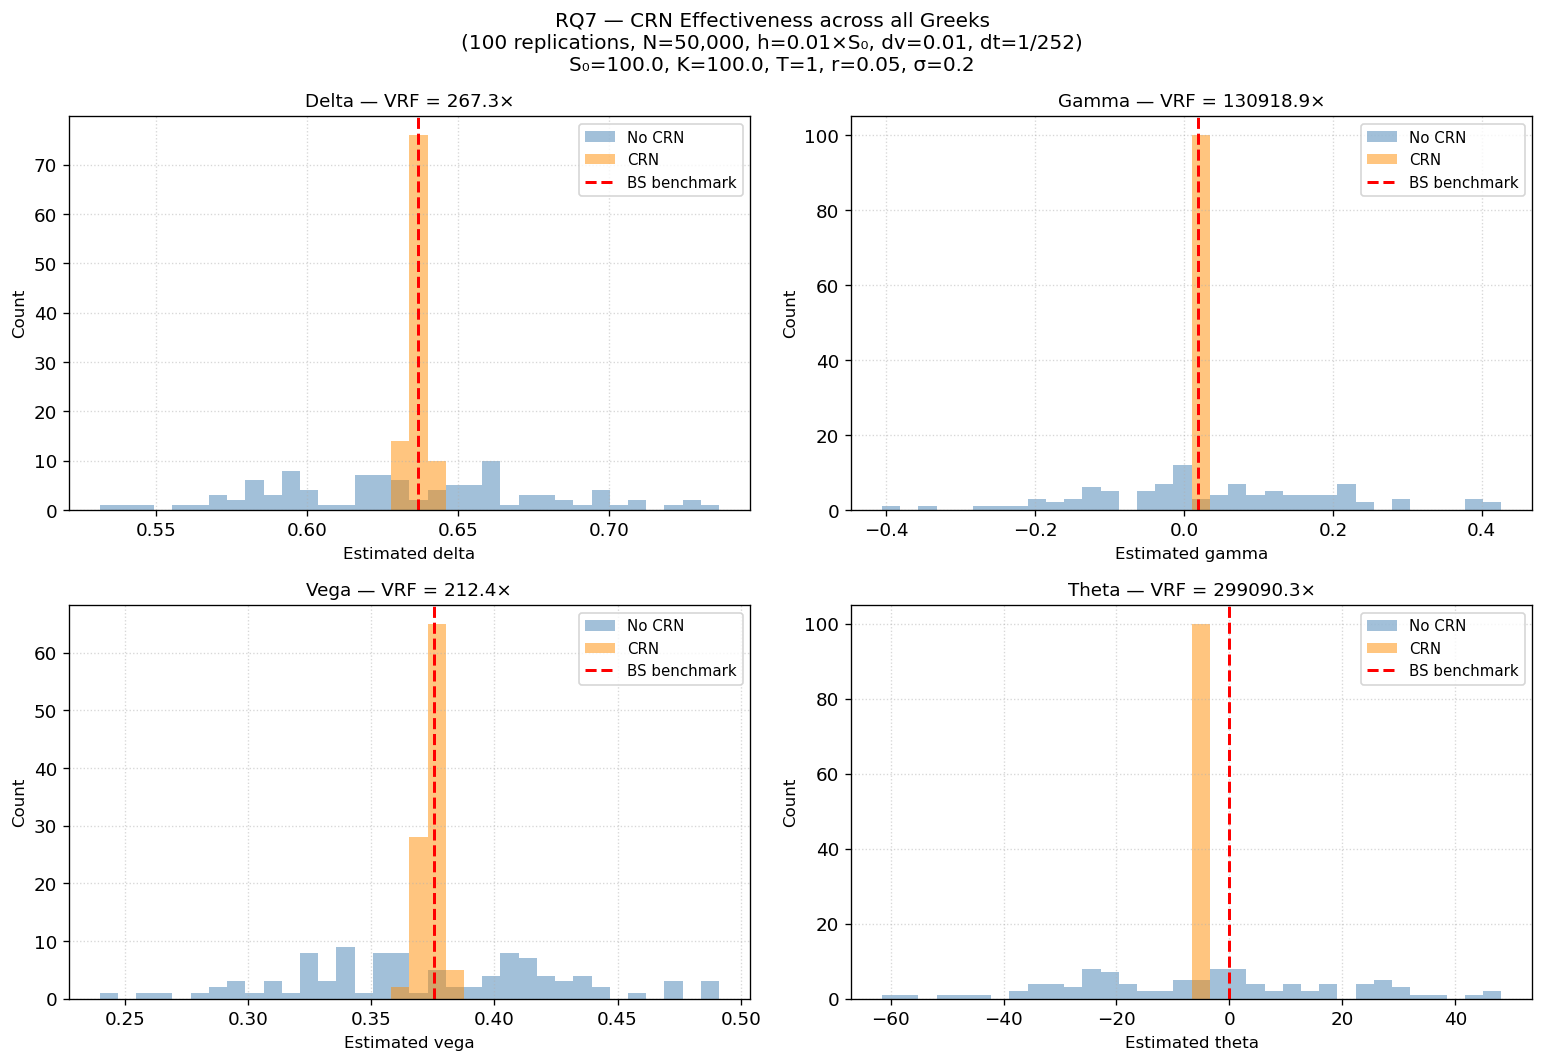

In [10]:
# ── Experiment ────────────────────────────────────────────────────────────────
def run_crn_experiment(
    S0: float, K: float, T: float, r: float, sigma: float,
    n_paths: int = 50_000,
    n_replications: int = 100,
) -> dict:
    h  = 0.01 * S0
    dv = 0.01
    dt = 1.0 / 252

    results = {g: {"crn": [], "no_crn": []} for g in ["delta", "gamma", "vega", "theta"]}

    for rep in range(n_replications):
        # ── CRN: same seed for every pricing call ─────────────────────────
        def _crn(S_=S0, sigma_=sigma, T_=T):
            return mc_european_option_price(
                S0=S_, K=K, T=T_, r=r, sigma=sigma_,
                n_paths=n_paths, antithetic=False, random_seed=rep,
            ).price

        base   = _crn()
        s_up   = _crn(S_=S0 + h)
        s_down = _crn(S_=S0 - h)
        v_up   = _crn(sigma_=sigma + dv)
        v_down = _crn(sigma_=sigma - dv)
        t_down = _crn(T_=T - dt)

        results["delta"]["crn"].append((s_up - s_down) / (2 * h))
        results["gamma"]["crn"].append((s_up - 2 * base + s_down) / h ** 2)
        results["vega"]["crn"].append((v_up - v_down) / (2 * dv) / 100)
        results["theta"]["crn"].append((t_down - base) / dt)

        # ── No CRN: independent seed for every pricing call ───────────────
        seed = lambda offset: 6 * rep + offset

        def _no_crn(S_=S0, sigma_=sigma, T_=T, offset=0):
            return mc_european_option_price(
                S0=S_, K=K, T=T_, r=r, sigma=sigma_,
                n_paths=n_paths, antithetic=False, random_seed=seed(offset),
            ).price

        base_n   = _no_crn(offset=0)
        s_up_n   = _no_crn(S_=S0 + h,       offset=1)
        s_down_n = _no_crn(S_=S0 - h,       offset=2)
        v_up_n   = _no_crn(sigma_=sigma + dv, offset=3)
        v_down_n = _no_crn(sigma_=sigma - dv, offset=4)
        t_down_n = _no_crn(T_=T - dt,        offset=5)

        results["delta"]["no_crn"].append((s_up_n - s_down_n) / (2 * h))
        results["gamma"]["no_crn"].append((s_up_n - 2 * base_n + s_down_n) / h ** 2)
        results["vega"]["no_crn"].append((v_up_n - v_down_n) / (2 * dv) / 100)
        results["theta"]["no_crn"].append((t_down_n - base_n) / dt)

    bs_vals = {
        "delta": bs_call_delta(S0, K, T, r, sigma),
        "gamma": bs_gamma(S0, K, T, r, sigma),
        "vega":  bs_vega(S0, K, T, r, sigma),
        "theta": bs_call_theta(S0, K, T, r, sigma),
    }

    return {
        g: {
            "crn":    np.array(results[g]["crn"]),
            "no_crn": np.array(results[g]["no_crn"]),
            "bs":     bs_vals[g],
        }
        for g in ["delta", "gamma", "vega", "theta"]
    }

# ── Plot ──────────────────────────────────────────────────────────────────────
crn_results = run_crn_experiment(S0, K, T, r, sigma)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, greek in zip(axes.flat, ["delta", "gamma", "vega", "theta"]):
    data        = crn_results[greek]
    crn_vals    = data["crn"]
    no_crn_vals = data["no_crn"]
    bs_val      = data["bs"]
    vrf         = np.var(no_crn_vals, ddof=1) / np.var(crn_vals, ddof=1)

    bins = np.linspace(
        min(crn_vals.min(), no_crn_vals.min()),
        max(crn_vals.max(), no_crn_vals.max()),
        35,
    )
    ax.hist(no_crn_vals, bins=bins, alpha=0.5, color="steelblue", label="No CRN")
    ax.hist(crn_vals,    bins=bins, alpha=0.5, color="darkorange", label="CRN")
    ax.axvline(bs_val, color="red", linestyle="--", linewidth=1.8, label="BS benchmark")

    ax.set_title(f"{greek.capitalize()} — VRF = {vrf:.1f}×", fontsize=11)
    ax.set_xlabel(f"Estimated {greek}", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle(
    f"RQ7 — CRN Effectiveness across all Greeks\n"
    f"(100 replications, N=50,000, h=0.01×S₀, dv=0.01, dt=1/252)\n"
    f"S₀={S0}, K={K}, T={T}, r={r}, σ={sigma}",
    fontsize=12,
)
plt.tight_layout()
plt.show()

Figure above shows the distribution of Greek estimates across 100 replications at N=50,000, comparing CRN (same seed for all pricing calls) against no CRN (independent seeds per call).
The result is unambiguous: CRN is not optional for finite-difference Greeks — it is essential. For Delta and Vega, removing CRN widens the distribution by factors of 267× and 212× respectively. For Gamma and Theta the effect is catastrophic: without CRN, Gamma estimates scatter from −0.4 to +0.4 against a true value of 0.019, and Theta estimates span from −60 to +45 against a true value of −0.025. The VRF reaches 130,919× for Gamma and 299,090× for Theta.
The mechanism is the same for all four Greeks: finite-difference numerators subtract near-equal MC prices, so the signal (the true derivative) is small relative to the noise of independent MC estimates. Without CRN, each bumped price carries independent sampling noise of order σ/√N, and the subtraction does not cancel it. With CRN, the same random paths experience the parameter bump, so the noise is fully correlated and cancels in the difference — leaving only the true parameter sensitivity.
Why does Theta show the most extreme VRF? Two reasons compound. First, the Theta numerator subtracts prices at very similar maturities (T and T − 1/252), producing the smallest signal of any Greek. Second, the result is divided by dt = 1/252 ≈ 0.004, which amplifies any residual noise by a factor of 252. Together these explain the 299,090× VRF.
The practical conclusion is that no risk system should compute finite-difference Greeks without CRN. The cost of CRN is zero — it is a design choice, not a resource tradeoff. The variance reduction obtained here is orders of magnitude beyond anything achievable with antithetic variates or other standard techniques.

---
## Experiment 7 — P&L Attribution Preview

This final experiment bridges from Greek estimation to the practical task 
that defines a P&L analyst's daily work: explaining option P&L using the 
Greek-based Taylor expansion.

For a long ATM call, we compare the actual P&L (obtained by repricing 
under Black-Scholes at the new spot) against two approximations across 
spot moves ΔS from −15 to +15:

- **First-order (Delta):**  ΔP&L ≈ Δ · ΔS
- **Second-order (Delta + Gamma):**  ΔP&L ≈ Δ · ΔS + ½ Γ · ΔS²

The residual between actual P&L and the approximation quantifies the 
higher-order "unexplained" term. This is precisely the decomposition a 
P&L analyst performs each morning to explain the prior day's option moves.

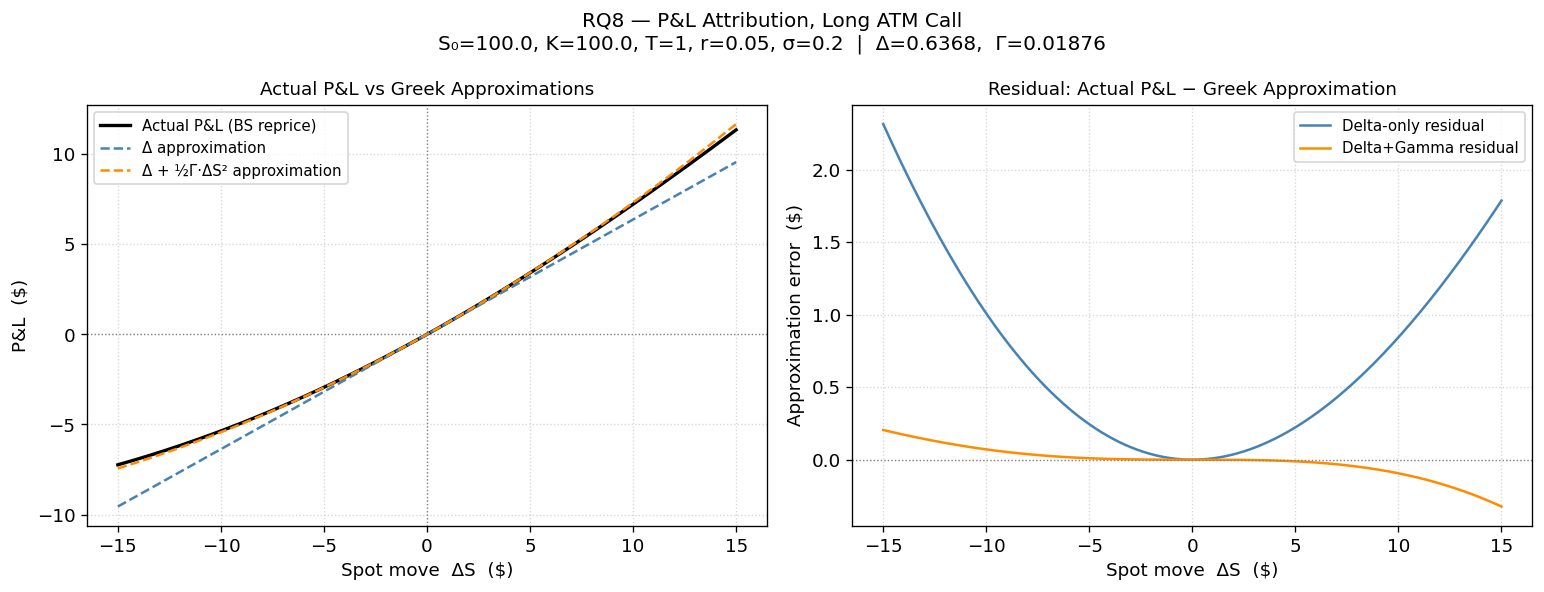

In [11]:
# ── Experiment ────────────────────────────────────────────────────────────────
def run_pnl_attribution_experiment(
    S0: float, K: float, T: float, r: float, sigma: float,
    ds_range: float = 15.0,
    n_points: int = 200,
) -> pd.DataFrame:
    """
    For a long ATM call, compare actual P&L (BS reprice) against
    first-order (Delta) and second-order (Delta + Gamma) Taylor approximations.
    """
    delta      = bs_call_delta(S0, K, T, r, sigma)
    gamma      = bs_gamma(S0, K, T, r, sigma)
    base_price = bs_call_price(S0, K, T, r, sigma)

    dS_grid         = np.linspace(-ds_range, ds_range, n_points)
    actual_pnl      = np.array([bs_call_price(S0 + dS, K, T, r, sigma) - base_price
                                for dS in dS_grid])
    delta_pnl       = delta * dS_grid
    delta_gamma_pnl = delta * dS_grid + 0.5 * gamma * dS_grid ** 2

    return pd.DataFrame({
        "dS":               dS_grid,
        "actual_pnl":       actual_pnl,
        "delta_pnl":        delta_pnl,
        "delta_gamma_pnl":  delta_gamma_pnl,
        "delta_error":      actual_pnl - delta_pnl,
        "delta_gamma_error": actual_pnl - delta_gamma_pnl,
    })


# ── Plot ──────────────────────────────────────────────────────────────────────
pnl_df = run_pnl_attribution_experiment(S0, K, T, r, sigma)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — P&L curves
ax = axes[0]
ax.plot(pnl_df["dS"], pnl_df["actual_pnl"],
        color="black",      linewidth=2.0, label="Actual P&L (BS reprice)")
ax.plot(pnl_df["dS"], pnl_df["delta_pnl"],
        color="steelblue",  linewidth=1.5, linestyle="--", label="Δ approximation")
ax.plot(pnl_df["dS"], pnl_df["delta_gamma_pnl"],
        color="darkorange", linewidth=1.5, linestyle="--", label="Δ + ½Γ·ΔS² approximation")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Spot move  ΔS  ($)", fontsize=11)
ax.set_ylabel("P&L  ($)", fontsize=11)
ax.set_title("Actual P&L vs Greek Approximations", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

# Right — Residuals
ax = axes[1]
ax.plot(pnl_df["dS"], pnl_df["delta_error"],
        color="steelblue",  linewidth=1.5, label="Delta-only residual")
ax.plot(pnl_df["dS"], pnl_df["delta_gamma_error"],
        color="darkorange", linewidth=1.5, label="Delta+Gamma residual")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Spot move  ΔS  ($)", fontsize=11)
ax.set_ylabel("Approximation error  ($)", fontsize=11)
ax.set_title("Residual: Actual P&L − Greek Approximation", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle(
    f"RQ8 — P&L Attribution, Long ATM Call\n"
    f"S₀={S0}, K={K}, T={T}, r={r}, σ={sigma}  |  "
    f"Δ={bs_call_delta(S0,K,T,r,sigma):.4f},  "
    f"Γ={bs_gamma(S0,K,T,r,sigma):.5f}",
    fontsize=12,
)
plt.tight_layout()
# plt.savefig("reports/figures/pnl_attribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Conclusions

This notebook answered four research questions on finite-difference Greek 
estimation for European options under Black-Scholes:

- **RQ5 — Convergence (Experiments 3, 4):** All four MC Greeks converge to 
  the analytical BS benchmarks at the theoretical O(N⁻¹/²) rate. The 
  convergence rate is identical across Greeks; only the prefactors differ. 
  At N = 500,000, all absolute errors are below 10⁻³.

- **RQ6 — Bump size (Experiment 5):** First-order Greeks (Delta, Vega, Theta) 
  show an L-shape with optima near f ≈ 0.006–0.03. The second-order Greek 
  (Gamma) shows a U-shape with an optimum near f ≈ 0.04 — larger than the 
  first-order Greeks because the second-order signal requires a bigger bump 
  to exceed MC noise. The library uses f = 0.01 as the market-standard 
  compromise, accepting a measurable but acceptable accuracy hit on Gamma.

- **RQ7 — CRN effectiveness (Experiment 6):** CRN is essential, not optional. 
  Variance reduction factors reach 267× for Delta, 212× for Vega, 130,919× 
  for Gamma, and 299,090× for Theta. Without CRN, Gamma and Theta estimates 
  are essentially noise.

- **RQ8 — P&L attribution (Experiment 7):** A Delta + ½Γ·ΔS² Taylor expansion 
  closely tracks actual option P&L for moderate spot moves (|ΔS| ≲ 10), with 
  growing residuals at larger moves. This is the empirical foundation for 
  Delta-Gamma hedging and direct preparation for a real-data P&L attribution 
  exercise.

## Next Steps

This notebook completes the Greeks chapter of the project. Subsequent work 
will move the framework toward real-data applications:

1. **Implied volatility solver** — invert Black-Scholes numerically using 
   Brent's method to recover implied vols from market option prices
2. **Real market data** — fetch SPY option chains via yfinance, compute the 
   implied volatility smile, and apply analytical Greeks to real strikes
3. **P&L attribution on a historical time series** — extend Experiment 7 
   to a real one-month SPY position using daily market moves
4. **Historical VaR with Kupiec backtest** — implement and validate a 
   one-day 99% Value-at-Risk on a simple option portfolio